In [1]:
# Cell 1: Reproducibility + basic imports
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:
# Cell 2: Install PyTorch Geometric
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00


In [3]:
# Cell 3: Load metadata (only what we need for Task 2 - no need to reload everything from Task 1)
import os
import pandas as pd

DATA_ROOT = "/kaggle/input/fma-free-music-archive-small-medium"

tracks_path = os.path.join(DATA_ROOT, "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata", "tracks.csv")
tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])

FMA_SMALL_ROOT = os.path.join(DATA_ROOT, "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small", "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small/fma_small")
subdirs = sorted(os.listdir(FMA_SMALL_ROOT))[:5]
print("Sample subfolders:", subdirs)

sample_subdir = os.path.join(FMA_SMALL_ROOT, subdirs[0])
sample_files = os.listdir(sample_subdir)[:5]
print("Sample files in", subdirs[0], ":", sample_files)

Sample subfolders: ['000', '001', '002', '003', '004']
Sample files in 000 : ['000207.mp3', '000213.mp3', '000666.mp3', '000210.mp3', '000602.mp3']


In [4]:
# Cell 5: Map track_id -> mp3 filepath, filtered to fma_small subset
def track_id_to_path(track_id, root=FMA_SMALL_ROOT):
    tid_str = f"{track_id:06d}"
    subfolder = tid_str[:3]
    return os.path.join(root, subfolder, f"{tid_str}.mp3")

# tracks.csv has a ('set', 'subset') column marking which tracks belong to small/medium/large
subset_col = tracks[("set", "subset")]
small_mask = subset_col == "small"
print("Tracks in fma_small (per metadata):", small_mask.sum())

genre_top_col = tracks[("track", "genre_top")]
small_df = pd.DataFrame({
    "track_id": tracks.index[small_mask],
    "genre_top": genre_top_col[small_mask].values
})
small_df = small_df.dropna(subset=["genre_top"])
small_df["filepath"] = small_df["track_id"].apply(track_id_to_path)

# Verify files actually exist
small_df["exists"] = small_df["filepath"].apply(os.path.exists)
print("Tracks with existing audio files:", small_df["exists"].sum(), "out of", len(small_df))
print(small_df["genre_top"].value_counts())

Tracks in fma_small (per metadata): 8000
Tracks with existing audio files: 8000 out of 8000
genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [5]:
# Cell 6: Test librosa loading on one track
import librosa
import librosa.display
import matplotlib.pyplot as plt
import time

sample_path = small_df["filepath"].iloc[0]
print("Loading:", sample_path)

start = time.time()
y, sr = librosa.load(sample_path, sr=22050)  # resample to 22050 Hz per assignment spec
elapsed = time.time() - start

print(f"Loaded in {elapsed:.2f}s")
print(f"Sample rate: {sr}, Duration: {len(y)/sr:.2f}s, Shape: {y.shape}")

Loading: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small/fma_small/000/000002.mp3
Loaded in 13.55s
Sample rate: 22050, Duration: 29.98s, Shape: (660984,)


Chroma shape: (12, 1291)


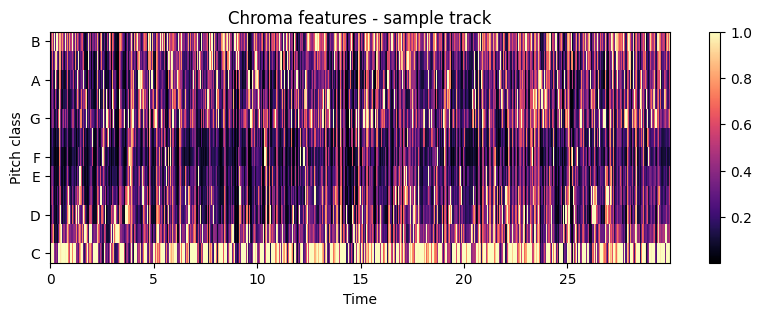

In [6]:
# Cell 7: Extract chroma features (12 bins) for the full track
chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)
print("Chroma shape:", chroma.shape)  # (12, num_frames)

plt.figure(figsize=(10, 3))
librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title("Chroma features - sample track")
plt.show()

In [7]:
# Cell 8: Segment the track into fixed 5-second windows and extract chroma per segment
SEGMENT_DURATION = 5.0  # seconds
hop_length = 512  # default librosa hop length
frames_per_segment = int(SEGMENT_DURATION * sr / hop_length)

n_segments = chroma.shape[1] // frames_per_segment
print(f"Track duration: {len(y)/sr:.1f}s -> {n_segments} segments of {SEGMENT_DURATION}s each")

segment_features = []
for i in range(n_segments):
    start_frame = i * frames_per_segment
    end_frame = start_frame + frames_per_segment
    segment_chroma = chroma[:, start_frame:end_frame]
    # Average pool across time within the segment -> one 12-dim vector per segment
    segment_vec = segment_chroma.mean(axis=1)
    segment_features.append(segment_vec)

segment_features = np.array(segment_features)
print("Segment features shape:", segment_features.shape)  # (n_segments, 12)

Track duration: 30.0s -> 6 segments of 5.0s each
Segment features shape: (6, 12)


In [8]:
# Cell 10: Install soxr for fast resampling
!pip install soxr -q

In [9]:
# Cell 11: Re-test timings with soxr, skip kaiser_fast
import time

sample_path = small_df["filepath"].iloc[0]

# Test 1: Load WITHOUT resampling (native sample rate)
start = time.time()
y_native, sr_native = librosa.load(sample_path, sr=None)
print(f"Load without resampling: {time.time()-start:.2f}s (native sr={sr_native})")

# Test 2: Load with soxr_hq resampling (fast, high quality)
start = time.time()
y_soxr, sr_soxr = librosa.load(sample_path, sr=22050, res_type='soxr_hq')
print(f"Load with soxr_hq resampling: {time.time()-start:.2f}s")

Load without resampling: 0.08s (native sr=44100)
Load with soxr_hq resampling: 0.08s


In [10]:
# Cell 12: Full per-track processing function
SEGMENT_DURATION = 5.0
SR = 22050

def extract_segment_features(filepath, sr=SR, segment_duration=SEGMENT_DURATION):
    """Load audio, extract chroma, segment into fixed windows, return (n_segments, 12) array."""
    y, _ = librosa.load(filepath, sr=sr, res_type='soxr_hq')
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)

    hop_length = 512
    frames_per_segment = int(segment_duration * sr / hop_length)
    n_segments = chroma.shape[1] // frames_per_segment

    if n_segments == 0:
        return None  # track too short to segment

    segments = []
    for i in range(n_segments):
        start_f = i * frames_per_segment
        end_f = start_f + frames_per_segment
        segments.append(chroma[:, start_f:end_f].mean(axis=1))

    return np.array(segments, dtype=np.float32)


# Test on 3 tracks with timing
start = time.time()
for i in range(3):
    feats = extract_segment_features(small_df["filepath"].iloc[i])
    print(f"Track {i}: shape={feats.shape if feats is not None else None}")
elapsed = time.time() - start
print(f"\nTotal for 3 tracks: {elapsed:.2f}s -> avg {elapsed/3:.2f}s/track")
print(f"Projected time for all 8000 tracks: {elapsed/3*8000/60:.1f} minutes")

Track 0: shape=(6, 12)
Track 1: shape=(6, 12)
Track 2: shape=(6, 12)

Total for 3 tracks: 0.47s -> avg 0.16s/track
Projected time for all 8000 tracks: 20.9 minutes


In [11]:
# Cell 13: Full batch extraction over all 8000 tracks, with progress + checkpointing
from tqdm.notebook import tqdm
import pickle

os.makedirs("/kaggle/working/graph_data", exist_ok=True)
CHECKPOINT_PATH = "/kaggle/working/graph_data/segment_features.pkl"
SAVE_EVERY = 500  # save progress every 500 tracks

all_features = {}  # track_id -> (n_segments, 12) array
failed_tracks = []

track_ids = small_df["track_id"].tolist()
filepaths = small_df["filepath"].tolist()

start_time = time.time()

for idx, (track_id, filepath) in enumerate(tqdm(zip(track_ids, filepaths), total=len(track_ids))):
    try:
        feats = extract_segment_features(filepath)
        if feats is not None and feats.shape[0] >= 2:  # need at least 2 segments for a graph
            all_features[track_id] = feats
        else:
            failed_tracks.append(track_id)
    except Exception as e:
        failed_tracks.append(track_id)

    if (idx + 1) % SAVE_EVERY == 0:
        with open(CHECKPOINT_PATH, "wb") as f:
            pickle.dump({"features": all_features, "failed": failed_tracks}, f)

# Final save
with open(CHECKPOINT_PATH, "wb") as f:
    pickle.dump({"features": all_features, "failed": failed_tracks}, f)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed/60:.1f} minutes")
print(f"Successfully processed: {len(all_features)} tracks")
print(f"Failed/too short: {len(failed_tracks)} tracks")

  0%|          | 0/8000 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
/tmp/ipykernel_23/1401402698.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  


Done in 22.7 minutes
Successfully processed: 7994 tracks
Failed/too short: 6 tracks


In [12]:
# Cell 14: Verify saved checkpoint and inspect the failed tracks
with open(CHECKPOINT_PATH, "rb") as f:
    saved_data = pickle.load(f)

all_features = saved_data["features"]
failed_tracks = saved_data["failed"]

print("Loaded features for", len(all_features), "tracks")
print("Failed track IDs:", failed_tracks)

# Peek at one example
sample_id = list(all_features.keys())[0]
print(f"\nExample - track {sample_id}: shape {all_features[sample_id].shape}")
print(all_features[sample_id])

Loaded features for 7994 tracks
Failed track IDs: [98565, 98567, 98569, 99134, 108925, 133297]

Example - track 2: shape (6, 12)
[[0.6726606  0.48816147 0.4132715  0.34848127 0.24516463 0.20745195
  0.2526141  0.3770956  0.33997908 0.32606983 0.33136788 0.47416526]
 [0.7429504  0.43977752 0.318072   0.28818044 0.24272083 0.19779426
  0.23132704 0.4086838  0.36981443 0.38616034 0.40773237 0.51855767]
 [0.7613091  0.46360898 0.34862185 0.30031183 0.2512083  0.23772655
  0.27608627 0.42170715 0.37298152 0.34909937 0.37297556 0.51498383]
 [0.7930273  0.4662875  0.3859543  0.37971145 0.30657053 0.25604427
  0.29708636 0.42429888 0.3328269  0.33350238 0.381297   0.53289247]
 [0.7712989  0.49313655 0.42519608 0.37840533 0.29366356 0.23861298
  0.2754602  0.42215016 0.42874467 0.3843042  0.37147874 0.5129887 ]
 [0.7396159  0.4420463  0.3699751  0.38273734 0.3167979  0.26695836
  0.30484453 0.46382165 0.38994405 0.36966693 0.40485805 0.53906626]]


In [13]:
# Cell 15: Build one PyG graph from a track's segment features (test on one track first)
from torch_geometric.data import Data
import torch

def build_graph(segment_features, similarity_threshold=0.9):
    """Build a PyG graph: nodes=segments, edges=temporal adjacency + cosine similarity."""
    n_nodes = segment_features.shape[0]
    x = torch.tensor(segment_features, dtype=torch.float32)  # node features (n_nodes, 12)

    edge_list = []

    # Temporal adjacency edges (undirected, so add both directions)
    for i in range(n_nodes - 1):
        edge_list.append([i, i + 1])
        edge_list.append([i + 1, i])

    # Cosine similarity edges (skip pairs already connected by adjacency)
    norm_feats = segment_features / (np.linalg.norm(segment_features, axis=1, keepdims=True) + 1e-8)
    sim_matrix = norm_feats @ norm_feats.T

    for i in range(n_nodes):
        for j in range(i + 2, n_nodes):  # skip self and immediate neighbors (already added)
            if sim_matrix[i, j] > similarity_threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)


# Test on the sample track
test_graph = build_graph(all_features[sample_id])
print(test_graph)
print("Number of nodes:", test_graph.num_nodes)
print("Number of edges:", test_graph.num_edges)

Data(x=[6, 12], edge_index=[2, 30])
Number of nodes: 6
Number of edges: 30


In [14]:
# Cell 16: Check edge density and similarity distribution across multiple tracks
sample_ids = list(all_features.keys())[:20]

for tid in sample_ids[:5]:
    feats = all_features[tid]
    n = feats.shape[0]
    norm_feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    sim_matrix = norm_feats @ norm_feats.T
    # Get off-diagonal, non-adjacent similarities
    non_adj_sims = []
    for i in range(n):
        for j in range(i + 2, n):
            non_adj_sims.append(sim_matrix[i, j])
    if non_adj_sims:
        print(f"Track {tid}: n_segments={n}, mean_sim={np.mean(non_adj_sims):.3f}, "
              f"min={np.min(non_adj_sims):.3f}, max={np.max(non_adj_sims):.3f}")
    else:
        print(f"Track {tid}: n_segments={n}, no non-adjacent pairs")

Track 2: n_segments=6, mean_sim=0.996, min=0.994, max=0.998
Track 5: n_segments=6, mean_sim=0.994, min=0.985, max=0.999
Track 10: n_segments=6, mean_sim=0.978, min=0.950, max=0.995
Track 140: n_segments=6, mean_sim=0.889, min=0.758, max=0.979
Track 141: n_segments=6, mean_sim=0.888, min=0.767, max=0.952


In [15]:
# Cell 17: Rebuild build_graph() using a per-track percentile threshold
def build_graph(segment_features, similarity_percentile=70):
    """Build a PyG graph: nodes=segments, edges=temporal adjacency + top-percentile cosine similarity."""
    n_nodes = segment_features.shape[0]
    x = torch.tensor(segment_features, dtype=torch.float32)

    edge_list = []
    # Temporal adjacency edges
    for i in range(n_nodes - 1):
        edge_list.append([i, i + 1])
        edge_list.append([i + 1, i])

    # Compute similarity for all non-adjacent pairs
    norm_feats = segment_features / (np.linalg.norm(segment_features, axis=1, keepdims=True) + 1e-8)
    sim_matrix = norm_feats @ norm_feats.T

    non_adj_pairs = []
    non_adj_sims = []
    for i in range(n_nodes):
        for j in range(i + 2, n_nodes):
            non_adj_pairs.append((i, j))
            non_adj_sims.append(sim_matrix[i, j])

    # Only add similarity edges if there ARE non-adjacent pairs to consider
    if len(non_adj_sims) > 0:
        threshold = np.percentile(non_adj_sims, similarity_percentile)
        for (i, j), sim in zip(non_adj_pairs, non_adj_sims):
            if sim >= threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)


# Re-test on the same tracks to see the new behavior
for tid in [2, 5, 10, 140, 141]:
    if tid in all_features:
        g = build_graph(all_features[tid])
        print(f"Track {tid}: nodes={g.num_nodes}, edges={g.num_edges}")

Track 2: nodes=6, edges=16
Track 5: nodes=6, edges=16
Track 10: nodes=6, edges=16
Track 140: nodes=6, edges=16
Track 141: nodes=6, edges=16


In [16]:
# Cell 18: Build genre label mapping (8 classes for fma_small)
genre_list = sorted(small_df["genre_top"].unique())
genre_to_idx = {g: i for i, g in enumerate(genre_list)}
print("Genre classes:", genre_to_idx)

track_id_to_genre = dict(zip(small_df["track_id"], small_df["genre_top"]))

Genre classes: {'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


In [17]:
# Cell 19: Build all graphs with labels attached
from tqdm.notebook import tqdm

all_graphs = []
skipped = 0

for track_id, feats in tqdm(all_features.items()):
    genre = track_id_to_genre.get(track_id)
    if genre is None:
        skipped += 1
        continue

    g = build_graph(feats, similarity_percentile=70)
    g.y = torch.tensor([genre_to_idx[genre]], dtype=torch.long)
    g.track_id = track_id  # keep for reference/debugging
    all_graphs.append(g)

print(f"Built {len(all_graphs)} graphs, skipped {skipped}")
print(f"Example graph: {all_graphs[0]}")

  0%|          | 0/7994 [00:00<?, ?it/s]

Built 7994 graphs, skipped 0
Example graph: Data(x=[6, 12], edge_index=[2, 16], y=[1], track_id=2)


In [18]:
# Cell 20: Artist-grouped train/val/test split (same leakage-avoidance principle as Task 1)
from sklearn.model_selection import GroupShuffleSplit

# Get artist_id per track for grouping
artist_id_col = tracks[("artist", "id")]
graph_track_ids = [g.track_id for g in all_graphs]
graph_artist_ids = [artist_id_col.get(tid) for tid in graph_track_ids]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(all_graphs, groups=graph_artist_ids))

train_graphs = [all_graphs[i] for i in train_idx]
temp_graphs = [all_graphs[i] for i in temp_idx]
temp_artist_ids = [graph_artist_ids[i] for i in temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_graphs, groups=temp_artist_ids))

val_graphs = [temp_graphs[i] for i in val_idx]
test_graphs = [temp_graphs[i] for i in test_idx]

print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

# Verify no artist leakage
train_artists = set(artist_id_col.get(g.track_id) for g in train_graphs)
val_artists = set(artist_id_col.get(g.track_id) for g in val_graphs)
test_artists = set(artist_id_col.get(g.track_id) for g in test_graphs)
print("Train/Val overlap:", len(train_artists & val_artists))
print("Train/Test overlap:", len(train_artists & test_artists))

Train: 6485, Val: 806, Test: 703
Train/Val overlap: 0
Train/Test overlap: 0


In [19]:
# Cell 21: PyTorch Geometric DataLoader (batches multiple graphs together)
from torch_geometric.loader import DataLoader as PyGDataLoader

BATCH_SIZE = 64

train_loader = PyGDataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = PyGDataLoader(val_graphs, batch_size=BATCH_SIZE)
test_loader = PyGDataLoader(test_graphs, batch_size=BATCH_SIZE)

# Sanity check one batch
batch = next(iter(train_loader))
print(batch)
print("Batch size (num graphs):", batch.num_graphs)
print("Total nodes in batch:", batch.num_nodes)
print("batch.batch (maps each node to its graph):", batch.batch[:20])

DataBatch(x=[384, 12], edge_index=[2, 1024], y=[64], track_id=[64], batch=[384], ptr=[65])
Batch size (num graphs): 64
Total nodes in batch: 384
batch.batch (maps each node to its graph): tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3])


In [20]:
# Cell 22: GraphSAGE model definition 
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=12, hidden_channels=64, num_classes=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))

        self.dropout = dropout
        self.classifier = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Graph-level readout: mean pool over all nodes belonging to each graph
        g = global_mean_pool(x, batch)  # (num_graphs_in_batch, hidden_channels)
        logits = self.classifier(g)
        return logits

model = GraphSAGEClassifier(in_channels=12, hidden_channels=64, num_classes=8).to(device)
print(model)

# Test forward pass on one batch
batch = batch.to(device)
out = model(batch.x, batch.edge_index, batch.batch)
print("Output shape:", out.shape)  # should be (batch_size, 8)

Using device: cuda
GraphSAGEClassifier(
  (convs): ModuleList(
    (0): SAGEConv(12, 64, aggr=mean)
    (1): SAGEConv(64, 64, aggr=mean)
  )
  (classifier): Linear(in_features=64, out_features=8, bias=True)
)
Output shape: torch.Size([64, 8])


In [21]:
# Cell 23: Evaluation function (accuracy + macro-F1 for genre classification)
from sklearn.metrics import f1_score, accuracy_score

def evaluate_gnn(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(logits, batch.y)
            total_loss += loss.item() * batch.num_graphs

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(batch.y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, acc, macro_f1

In [22]:
# Cell 24: Training loop with early stopping 
import copy
import time

model = GraphSAGEClassifier(in_channels=12, hidden_channels=64, num_classes=8).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

MAX_EPOCHS = 30
PATIENCE = 5

best_val_f1 = -1.0
best_model_state = None
epochs_no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

for epoch in range(MAX_EPOCHS):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch.num_graphs

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_macro_f1 = evaluate_gnn(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
          f"val_macro_f1={val_macro_f1:.4f} | time={elapsed:.1f}s")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"  -> New best val_macro_f1: {best_val_f1:.4f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)
print(f"\nBest val_macro_f1 achieved: {best_val_f1:.4f}")

Epoch 1/30 | train_loss=2.0430 | val_loss=1.9724 | val_acc=0.1712 | val_macro_f1=0.1052 | time=1.0s
  -> New best val_macro_f1: 0.1052 (checkpoint saved)
Epoch 2/30 | train_loss=1.9494 | val_loss=1.8972 | val_acc=0.2097 | val_macro_f1=0.1481 | time=0.6s
  -> New best val_macro_f1: 0.1481 (checkpoint saved)
Epoch 3/30 | train_loss=1.9158 | val_loss=1.8808 | val_acc=0.2581 | val_macro_f1=0.1982 | time=0.6s
  -> New best val_macro_f1: 0.1982 (checkpoint saved)
Epoch 4/30 | train_loss=1.8924 | val_loss=1.8598 | val_acc=0.2655 | val_macro_f1=0.2119 | time=0.6s
  -> New best val_macro_f1: 0.2119 (checkpoint saved)
Epoch 5/30 | train_loss=1.8818 | val_loss=1.8543 | val_acc=0.2705 | val_macro_f1=0.2236 | time=0.6s
  -> New best val_macro_f1: 0.2236 (checkpoint saved)
Epoch 6/30 | train_loss=1.8665 | val_loss=1.8585 | val_acc=0.2717 | val_macro_f1=0.2222 | time=0.5s
  -> No improvement for 1 epoch(s)
Epoch 7/30 | train_loss=1.8542 | val_loss=1.8392 | val_acc=0.2965 | val_macro_f1=0.2452 | time=

In [23]:
# Cell 25: Final test evaluation
test_loss, test_acc, test_macro_f1 = evaluate_gnn(model, test_loader, device)
print(f"TEST SET -> loss={test_loss:.4f} | acc={test_acc:.4f} | macro_f1={test_macro_f1:.4f}")

TEST SET -> loss=1.8825 | acc=0.2817 | macro_f1=0.2761


In [24]:
# Cell 26: Save checkpoint, config, and training history
import json

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

torch.save(model.state_dict(), "/kaggle/working/checkpoints/task2_gnn_classifier.pt")

with open("/kaggle/working/results/task2_history.json", "w") as f:
    json.dump(history, f, indent=2)

with open("/kaggle/working/results/task2_config.json", "w") as f:
    json.dump({
        "genre_to_idx": genre_to_idx,
        "in_channels": 12,
        "hidden_channels": 64,
        "num_layers": 2,
        "similarity_percentile": 70,
        "segment_duration": SEGMENT_DURATION,
        "test_acc": test_acc,
        "test_macro_f1": test_macro_f1
    }, f, indent=2)

print("Saved checkpoint and results.")

Saved checkpoint and results.


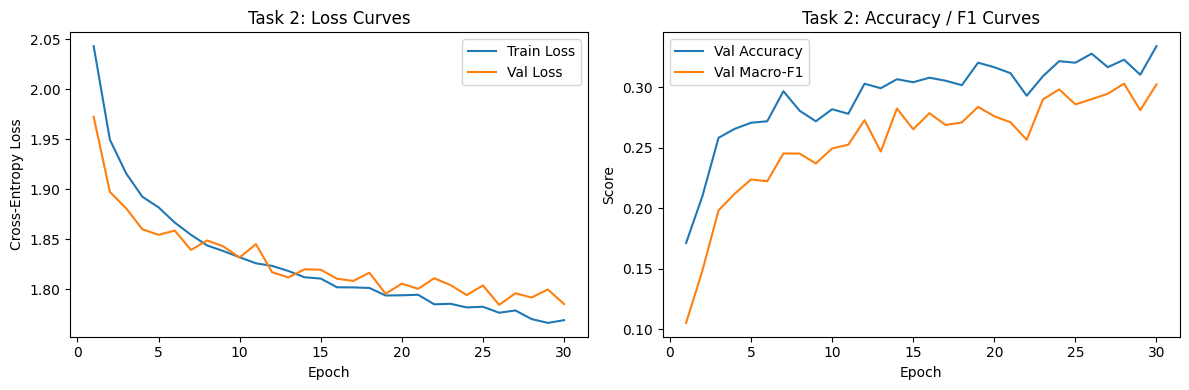

In [25]:
# Cell 27: Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Task 2: Loss Curves")
axes[0].legend()

axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy")
axes[1].plot(epochs_range, history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Task 2: Accuracy / F1 Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/results/task2_curves.png", dpi=150)
plt.show()

Extracted in 0.12s, shape: (128, 660)


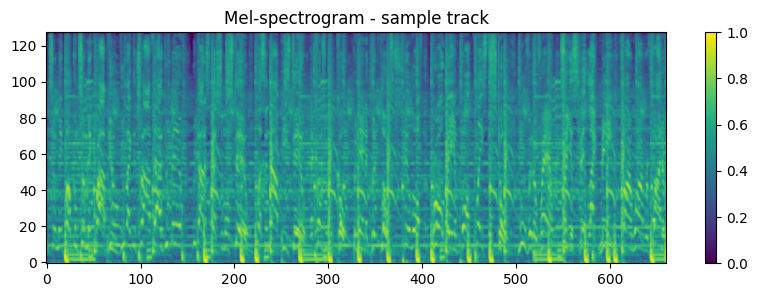

In [26]:
# Cell 28: Extract mel-spectrograms for CNN baseline (reuse cached audio loading logic)
N_MELS = 128
FIXED_TIME_FRAMES = 660  # ~30s at hop_length=512, sr=22050 -> we'll pad/truncate to this

def extract_mel_spectrogram(filepath, sr=SR, n_mels=N_MELS, fixed_frames=FIXED_TIME_FRAMES):
    y, _ = librosa.load(filepath, sr=sr, res_type='soxr_hq')
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # log scale, standard practice

    # Pad or truncate to fixed_frames so all tracks give same-shape input
    if mel_db.shape[1] < fixed_frames:
        pad_width = fixed_frames - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=mel_db.min())
    else:
        mel_db = mel_db[:, :fixed_frames]

    # Normalize to [0, 1] per-track
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_db.astype(np.float32)  # shape (128, 660)

# Test on one track + time it
start = time.time()
test_mel = extract_mel_spectrogram(small_df["filepath"].iloc[0])
print(f"Extracted in {time.time()-start:.2f}s, shape: {test_mel.shape}")

plt.figure(figsize=(10, 3))
plt.imshow(test_mel, aspect='auto', origin='lower')
plt.title("Mel-spectrogram - sample track")
plt.colorbar()
plt.show()

In [27]:
# Cell 29: Full batch extraction of mel-spectrograms (same tracks as before, for fair comparison)
from tqdm.notebook import tqdm
import pickle

os.makedirs("/kaggle/working/mel_data", exist_ok=True)
MEL_CHECKPOINT_PATH = "/kaggle/working/mel_data/mel_spectrograms.pkl"
SAVE_EVERY = 500

all_mels = {}
failed_mel_tracks = []

# Reuse the SAME track set as the GNN graphs, for a fair apples-to-apples comparison
track_ids_for_cnn = list(all_features.keys())
filepaths_for_cnn = [small_df.set_index("track_id").loc[tid, "filepath"] for tid in track_ids_for_cnn]

start_time = time.time()

for idx, (track_id, filepath) in enumerate(tqdm(zip(track_ids_for_cnn, filepaths_for_cnn), total=len(track_ids_for_cnn))):
    try:
        mel = extract_mel_spectrogram(filepath)
        all_mels[track_id] = mel
    except Exception as e:
        failed_mel_tracks.append(track_id)

    if (idx + 1) % SAVE_EVERY == 0:
        with open(MEL_CHECKPOINT_PATH, "wb") as f:
            pickle.dump({"mels": all_mels, "failed": failed_mel_tracks}, f)

with open(MEL_CHECKPOINT_PATH, "wb") as f:
    pickle.dump({"mels": all_mels, "failed": failed_mel_tracks}, f)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed/60:.1f} minutes")
print(f"Successfully processed: {len(all_mels)} tracks")
print(f"Failed: {len(failed_mel_tracks)} tracks")

  0%|          | 0/7994 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)



Done in 19.5 minutes
Successfully processed: 7994 tracks
Failed: 0 tracks


In [28]:
# Cell 30: Build a PyTorch Dataset for mel-spectrograms, using the SAME train/val/test track_ids as the GNN split
from torch.utils.data import Dataset, DataLoader

# Extract track_ids from each GNN graph split to keep the split identical
train_ids_cnn = [g.track_id for g in train_graphs]
val_ids_cnn = [g.track_id for g in val_graphs]
test_ids_cnn = [g.track_id for g in test_graphs]

class MelSpectrogramDataset(Dataset):
    def __init__(self, track_ids, mel_dict, label_dict, genre_to_idx):
        self.track_ids = track_ids
        self.mel_dict = mel_dict
        self.label_dict = label_dict
        self.genre_to_idx = genre_to_idx

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        tid = self.track_ids[idx]
        mel = self.mel_dict[tid]  # (128, 660)
        label = self.genre_to_idx[self.label_dict[tid]]
        # Add channel dimension for CNN: (1, 128, 660)
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        return mel_tensor, torch.tensor(label, dtype=torch.long)

train_cnn_ds = MelSpectrogramDataset(train_ids_cnn, all_mels, track_id_to_genre, genre_to_idx)
val_cnn_ds = MelSpectrogramDataset(val_ids_cnn, all_mels, track_id_to_genre, genre_to_idx)
test_cnn_ds = MelSpectrogramDataset(test_ids_cnn, all_mels, track_id_to_genre, genre_to_idx)

CNN_BATCH_SIZE = 32
train_cnn_loader = DataLoader(train_cnn_ds, batch_size=CNN_BATCH_SIZE, shuffle=True)
val_cnn_loader = DataLoader(val_cnn_ds, batch_size=CNN_BATCH_SIZE)
test_cnn_loader = DataLoader(test_cnn_ds, batch_size=CNN_BATCH_SIZE)

# Sanity check
sample_x, sample_y = next(iter(train_cnn_loader))
print("Batch X shape:", sample_x.shape)  # (32, 1, 128, 660)
print("Batch Y shape:", sample_y.shape)

Batch X shape: torch.Size([32, 1, 128, 660])
Batch Y shape: torch.Size([32])


In [29]:
# Cell 31: Simple CNN model for genre classification
class MelCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # After 3 pools of stride 2 on (128, 660): (128/8, 660/8) = (16, 82)
        self.fc1 = nn.Linear(64 * 16 * 82, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

cnn_model = MelCNN(num_classes=8).to(device)
print(cnn_model)

# Test forward pass
sample_x = sample_x.to(device)
out = cnn_model(sample_x)
print("Output shape:", out.shape)  # should be (32, 8)

MelCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=83968, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=8, bias=True)
)
Output shape: torch.Size([32, 8])


In [30]:
# Cell 32: Evaluation function for CNN
def evaluate_cnn(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, acc, macro_f1

In [31]:
# Cell 33: Training loop
cnn_model = MelCNN(num_classes=8).to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

MAX_EPOCHS = 30
PATIENCE = 5

best_val_f1 = -1.0
best_cnn_state = None
epochs_no_improve = 0

cnn_history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

for epoch in range(MAX_EPOCHS):
    cnn_model.train()
    start_time = time.time()
    running_loss = 0.0

    for x, y in train_cnn_loader:
        x, y = x.to(device), y.to(device)
        cnn_optimizer.zero_grad()
        logits = cnn_model(x)
        loss = criterion(logits, y)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_cnn_loader.dataset)
    val_loss, val_acc, val_macro_f1 = evaluate_cnn(cnn_model, val_cnn_loader, device)

    cnn_history["train_loss"].append(train_loss)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
    cnn_history["val_macro_f1"].append(val_macro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
          f"val_macro_f1={val_macro_f1:.4f} | time={elapsed:.1f}s")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_cnn_state = copy.deepcopy(cnn_model.state_dict())
        epochs_no_improve = 0
        print(f"  -> New best val_macro_f1: {best_val_f1:.4f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

cnn_model.load_state_dict(best_cnn_state)
print(f"\nBest val_macro_f1 achieved: {best_val_f1:.4f}")

Epoch 1/30 | train_loss=1.9476 | val_loss=1.8476 | val_acc=0.3375 | val_macro_f1=0.2788 | time=10.2s
  -> New best val_macro_f1: 0.2788 (checkpoint saved)
Epoch 2/30 | train_loss=1.7630 | val_loss=1.6647 | val_acc=0.4144 | val_macro_f1=0.3669 | time=10.1s
  -> New best val_macro_f1: 0.3669 (checkpoint saved)
Epoch 3/30 | train_loss=1.6743 | val_loss=1.6071 | val_acc=0.4330 | val_macro_f1=0.4046 | time=10.2s
  -> New best val_macro_f1: 0.4046 (checkpoint saved)
Epoch 4/30 | train_loss=1.6286 | val_loss=1.5652 | val_acc=0.4591 | val_macro_f1=0.4334 | time=10.3s
  -> New best val_macro_f1: 0.4334 (checkpoint saved)
Epoch 5/30 | train_loss=1.5858 | val_loss=1.5327 | val_acc=0.4504 | val_macro_f1=0.4066 | time=10.4s
  -> No improvement for 1 epoch(s)
Epoch 6/30 | train_loss=1.5513 | val_loss=1.4906 | val_acc=0.4876 | val_macro_f1=0.4526 | time=10.4s
  -> New best val_macro_f1: 0.4526 (checkpoint saved)
Epoch 7/30 | train_loss=1.5106 | val_loss=1.4716 | val_acc=0.4839 | val_macro_f1=0.4661 |

In [32]:
# Cell 34: Final test evaluation for CNN
test_loss_cnn, test_acc_cnn, test_macro_f1_cnn = evaluate_cnn(cnn_model, test_cnn_loader, device)
print(f"CNN TEST SET -> loss={test_loss_cnn:.4f} | acc={test_acc_cnn:.4f} | macro_f1={test_macro_f1_cnn:.4f}")

CNN TEST SET -> loss=1.5496 | acc=0.4395 | macro_f1=0.4210


In [33]:
# Cell 35: Save CNN checkpoint, history, and build the final comparison table
torch.save(cnn_model.state_dict(), "/kaggle/working/checkpoints/task2_cnn_baseline.pt")

with open("/kaggle/working/results/task2_cnn_history.json", "w") as f:
    json.dump(cnn_history, f, indent=2)

comparison_table = {
    "GNN (GraphSAGE)": {"test_acc": test_acc, "test_macro_f1": test_macro_f1},
    "CNN (mel-spectrogram)": {"test_acc": test_acc_cnn, "test_macro_f1": test_macro_f1_cnn}
}

with open("/kaggle/working/results/task2_comparison_table.json", "w") as f:
    json.dump(comparison_table, f, indent=2)

print("Comparison table:")
for model_name, metrics in comparison_table.items():
    print(f"  {model_name}: acc={metrics['test_acc']:.4f}, macro_f1={metrics['test_macro_f1']:.4f}")

Comparison table:
  GNN (GraphSAGE): acc=0.2817, macro_f1=0.2761
  CNN (mel-spectrogram): acc=0.4395, macro_f1=0.4210


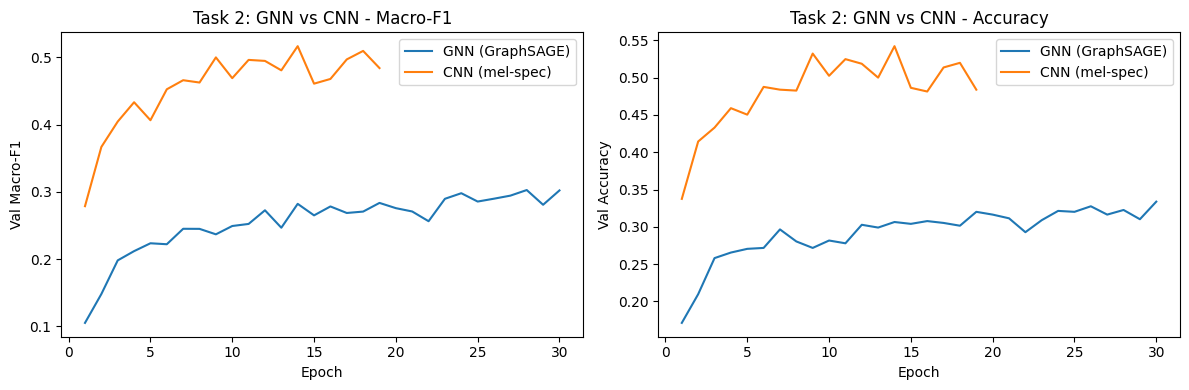

In [34]:
# Cell 36: Combined plot - GNN vs CNN training curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gnn_epochs = range(1, len(history["val_macro_f1"]) + 1)
cnn_epochs = range(1, len(cnn_history["val_macro_f1"]) + 1)

axes[0].plot(gnn_epochs, history["val_macro_f1"], label="GNN (GraphSAGE)")
axes[0].plot(cnn_epochs, cnn_history["val_macro_f1"], label="CNN (mel-spec)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Macro-F1")
axes[0].set_title("Task 2: GNN vs CNN - Macro-F1")
axes[0].legend()

axes[1].plot(gnn_epochs, history["val_acc"], label="GNN (GraphSAGE)")
axes[1].plot(cnn_epochs, cnn_history["val_acc"], label="CNN (mel-spec)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Accuracy")
axes[1].set_title("Task 2: GNN vs CNN - Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/results/task2_gnn_vs_cnn_comparison.png", dpi=150)
plt.show()